# Introduction
This section outlines the workflow and statistical techniques used to replicate the study.
1. **Libraries**: The analysis is built upon `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for visualization, and `statsmodels` for statistical modeling and estimation.
2. **Data Dictionary**: I developed a function (`var_labels`) that extracts the variables and their labels from the Stata dataset and converts them into a DataFrame to make it easier to search for the relevant variables. This imitates the experience in Stata, and it will be used whenever a new dataset is imported.
3. **Statistical Analysis**: All models are estimated using `statsmodels`:
   - **Baseline Regressions**: Initial estimations implement Ordinary Least Squares (OLS), to identify the relationship between religiosity and economic outcomes.
   - **Robustness & Fixed Effects**: Subsequent specifications expand the analysis by including control variables, department, and cohort fixed effects.
   - **Clustered Standard Errors**: To address spatial correlation, clustered standard errors at the district level are implemented using `cov_type` and `cov_kwds` in the `.fit()` method.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf 
from statsmodels.iolib.summary2 import summary_col

In [2]:
def var_labels(data_path):
    stata_reader = pd.read_stata(data_path, iterator=True)
    labels_dict = stata_reader.variable_labels()
    data_dictionary = pd.DataFrame(columns=["Variable", "Label"], 
                                   data=list(labels_dict.items()))
    return data_dictionary

# First Task: Relationship between religiosity and economic development
For this task, I replicate Table 2 and 3, which shows a negative relationship between religiosity intensity and economic development. In particular, it demonstrates that this negative association emerged during the Second Industrial Revolution and did not exist before.



In [3]:
dept_data  = pd.read_stata("Data/1.dept_dataset.dta")
dept_labels = var_labels("Data/1.dept_dataset.dta")
dept_labels

,Variable,Label
0,department_name,Nom de l'unité d'analyse
1,department_id,ID department
2,pop1841,Population 1841
3,pop1866,Population 1866
4,pop1886,Population 1886
...,...,...
103,lnpop1881,Population 1881
104,lnpop1891,Population 1891
105,lnpop1901,Population 1901
106,Bretagne,Department in the Bretagne Region


In [4]:
model1 = smf.ols(formula="share_ind_work1901 ~ share_refractory", data=dept_data).fit(cov_type="HC1")
model2 = smf.ols(formula="machines_pc ~ share_refractory", data=dept_data).fit(cov_type="HC1")
model3 = smf.ols(formula="share_ind_work1866 ~ share_refractory", data=dept_data).fit(cov_type="HC1")
model4 = smf.ols(formula="steam_engine_pc ~ share_refractory", data=dept_data).fit(cov_type="HC1")

table2 = summary_col([model1, model2, model3, model4], 
            stars=True, 
            float_format="%.3f",
            info_dict={ "Obs" : lambda x : f"{x.nobs:.0f}"},
            model_names=["(1) Share ind. workers 1901", "(2) Machines pc, 1891", "(3) Share ind. workers 1866", "(4) Steam eng. pc, 1840"],
            regressor_order=["share_refractory"],
            drop_omitted=True,
            )
table2

,(1) Share ind. workers 1901,"(2) Machines pc, 1891",(3) Share ind. workers 1866,"(4) Steam eng. pc, 1840"
share_refractory,-0.146*,-0.863**,-0.027,0.029
,(0.085),(0.397),(0.080),(0.052)
R-squared,0.037,0.062,0.001,0.008
R-squared Adj.,0.025,0.050,-0.011,-0.005
Obs,83,83,83,81


The equation uses the share of refractory clergy as a proxy for the intensity of religiosity at the local level. Columns 1 and 2 show that a 10% increase in the share is associated with 1.46 and 8.63 percentage-point decreases in the share of the industrial workforce and in the adoption of machines. Columns 3 and 4 represent a placebo test, which illustrates how this relationship did not exist before the Second Industrial Revolution, as the coefficients are not statistically significant.

In [5]:
regressors1 = ["share_refractory","lnpop1901", "mean_lntemp", "mean_lnprec", "wheat_suit","lnproto_ind", "lndist_Paris", "pays_elections", "lnsub_dept", "enrol_rate1891"]
regressors2 = ["share_refractory","lnpop1891", "mean_lntemp", "mean_lnprec", "wheat_suit","lnproto_ind", "lndist_Paris", "pays_elections", "lnsub_dept", "enrol_rate1881"]

In [6]:
model1 = smf.ols(formula=f"share_ind_work1901 ~ {"+".join(regressors1[:-4])}", data=dept_data).fit(cov_type="HC1") 
model2 = smf.ols(formula=f"machines_pc ~ {"+".join(regressors2[:-4])}", data=dept_data).fit(cov_type="HC1")
model3 = smf.ols(formula=f"share_ind_work1901 ~ {"+".join(regressors1[:-2])}", data=dept_data).fit(cov_type="HC1")
model4 = smf.ols(formula=f"machines_pc ~ {"+".join(regressors2[:-2])}", data=dept_data).fit(cov_type="HC1")
model5 = smf.ols(formula=f"share_ind_work1901 ~ {"+".join(regressors1)}", data=dept_data).fit(cov_type="HC1")
model6 = smf.ols(formula=f"machines_pc ~ {"+".join(regressors2)}", data=dept_data).fit(cov_type="HC1")

reg_order = ["share_refractory","lnpop1901","lnpop1891", "mean_lntemp", "mean_lnprec", "wheat_suit","lnproto_ind","lndist_Paris", "pays_elections", "lnsub_dept", "enrol_rate1881"]

In [7]:
table3 = summary_col([model1, model2, model3, model4, model5, model6], 
            float_format="%.3f", 
            stars=True, 
            regressor_order=reg_order,
            drop_omitted=True,
            info_dict= {"Obs" : lambda x : f"{x.nobs:.0f}"},
            model_names=["Share ind.workers, 1901", "Machinespc, 1891"] * 3)
table3

,"Share ind.workers, 1901 I","Machinespc, 1891 I","Share ind.workers, 1901 II","Machinespc, 1891 II","Share ind.workers, 1901 III","Machinespc, 1891 III"
share_refractory,-0.187***,-1.382***,-0.173**,-1.277***,-0.149**,-1.133***
,(0.059),(0.294),(0.077),(0.304),(0.073),(0.297)
lnpop1901,0.159***,,0.137***,,0.131***,
,(0.025),,(0.036),,(0.041),
lnpop1891,,0.612***,,0.331,,0.260
,,(0.145),,(0.209),,(0.228)
mean_lntemp,-0.030,0.252,-0.028,0.271,0.056,0.462
,(0.085),(0.345),(0.086),(0.312),(0.102),(0.331)
mean_lnprec,-0.151**,-0.786**,-0.128*,-0.542*,-0.142**,-0.541**
,(0.062),(0.331),(0.067),(0.277),(0.061),(0.258)


Table 3 introduces a vector of controls to account for potential confounders. These include population, geographical controls (temperature, precipitation, wheat suitability), pre-industrial activities, and institutional reach (distance from Paris, Pays d'èlection). Among them, only the likelihood of precipitation and pre-industrial activities are statistically significant. However, the `share_refractory` coefficient remains consistent and significant across all the specifications, confirming its link to industrial development.

# Second Task: Driving mechanism behind the relationship
In this task, I investigate the mechanism behind the relationship identified in the first task. The results show that areas with a higher level of religiosity were associated with a preference for religious education over the secular, technical curricula introduced by the French State. Moreover, catholic education was negativaly associated with employment in modern sectors.

I use 3 different datasets to replicate Table 7 (columns 4 and 7), Figure 2, and Table 12.

In [8]:
cantons_data = pd.read_stata("Data/2b.canton_dataset_schooling.dta")
cantons_labels = var_labels("Data/2b.canton_dataset_schooling.dta")

schools_data = pd.read_stata("Data/cath_sec_schools.dta")
schools_labels = var_labels("Data/cath_sec_schools.dta")

### Table 7 - The Schooling Mechanism

In [9]:
regressors1 = ["share_refractory", "lnschools_total", "lnstud_ps", "lnpopulation"] 
regressors2 = ["share_refractory", "gr_population", "share_cath_schools_l", "lnstud_ps_l", "lnschools_total_l", "wheat_suit", "lndist_Paris", "lnsubs"]
order = regressors1 + regressors2[1:]

In [10]:
model1 = smf.ols(formula=f"share_cath_schools ~ + {"+".join(regressors1[:-1])} + C(department_id)", data=cantons_data.query("year == 1894"))
clusters = cantons_data.query("year == 1894").loc[model1.data.row_labels, "district_id"] 
# this filters this clustering column using only the rows considered in the estimation, otherwise statsmodels would raise an error because district_id observations would be higher than those the model used.
col4 = model1.fit(cov_type="cluster", cov_kwds={"groups" : clusters})


model2= smf.ols(formula=f"gr_share_cath_schools ~ + {"+".join(regressors2[:-1])} + C(department_id)", data=cantons_data.query("year==1894")) 
clusters = cantons_data.query("year == 1894").loc[model2.data.row_labels, "district_id"]
col7 = model2.fit(cov_type="cluster", cov_kwds={"groups" : clusters})

In [11]:
table7 = summary_col([col4, col7],
            regressor_order=order, 
            drop_omitted=True,
            stars=True,
            float_format="%.3f",
            info_dict={"N" : lambda x : f"{x.nobs:.0f}"},
            model_names=["Share Catholic Schools 1894", "Growth Share Catholic Schools 1873-1894"])
table7

,Share Catholic Schools 1894,Growth Share Catholic Schools 1873-1894
share_refractory,0.099***,0.143**
,(0.017),(0.068)
lnschools_total,0.014**,
,(0.007),
lnstud_ps,0.114***,
,(0.008),
gr_population,,0.042
,,(0.066)
share_cath_schools_l,,-1.595***
,,(0.123)


The table shows that a higher degree of religiosity was associated with a higher proportion of Catholic schools and experienced a more significant growth rate in the presence of these schools. 

The coefficient of interest is statistically significant in both specifications. The model incorporates department-level controls to address potential omitted variable bias, such as population, the total number of schools, and number of students per school.

Standard errors are clustered at the district level. This adjustment is necessary because observations within each canton are not independent and may exhibit similar characteristics. Clustering prevents the standard errors from being too small and ensures the validity of the statistical inference.

The controls address potential omitted variable bias, while department fixed effects account for all time-invariant characteristics of each canton. These characteristics may include their geography or culture. In particular, the latter could influence the education content in each canton, so it is essential to control for it and for similar factors.


### Figure 2 - Divergence in education

Data required to be prepared in order to be correctly visualized. I briefly outline the steps I followed:
1. Created two new columns consisting of the sum of secular and catholic schools (both public and private).
2. Grouped data by year and summed the number of schools for each of them.
3. Renamed columns and changed their order to produce neater labels.
4. Converted the dataset into long format.
5. Created a column that checks whether the number refers to secular or Catholic schools. This will be used to produce two different plots, one for each type of school.


In [12]:

schools_data = schools_data.assign(
    tot_cath_schools = schools_data["schools_priv_cath"] + schools_data["schools_pub_cath"],
    tot_lay_schools =
schools_data["schools_priv_lay"] + schools_data["schools_pub_lay"]
)

schools_data_years = schools_data.groupby("year").sum().reset_index()
schools_data_years.columns = ["year", "department_id", "Public Secular Schools", "Public Catholic Schools",
                                          "Private Secular Schools", "Private Catholic Schools",
                                          "Total Catholic Schools", "Total Secular Schools"]
schools_data_years = schools_data_years.reindex(labels = ["year", "department_id", "Total Catholic Schools", "Public Catholic Schools", "Private Catholic Schools", "Total Secular Schools", "Public Secular Schools", "Private Secular Schools"], axis=1)

schools_long = schools_data_years.melt(id_vars="year", 
                                 value_vars=schools_data_years.iloc[:, 2:], 
                                 var_name="School Type",
                                 value_name="Total")
schools_long = schools_long.assign(cath = np.where(schools_long["School Type"].str.contains("Catholic"), True, False))

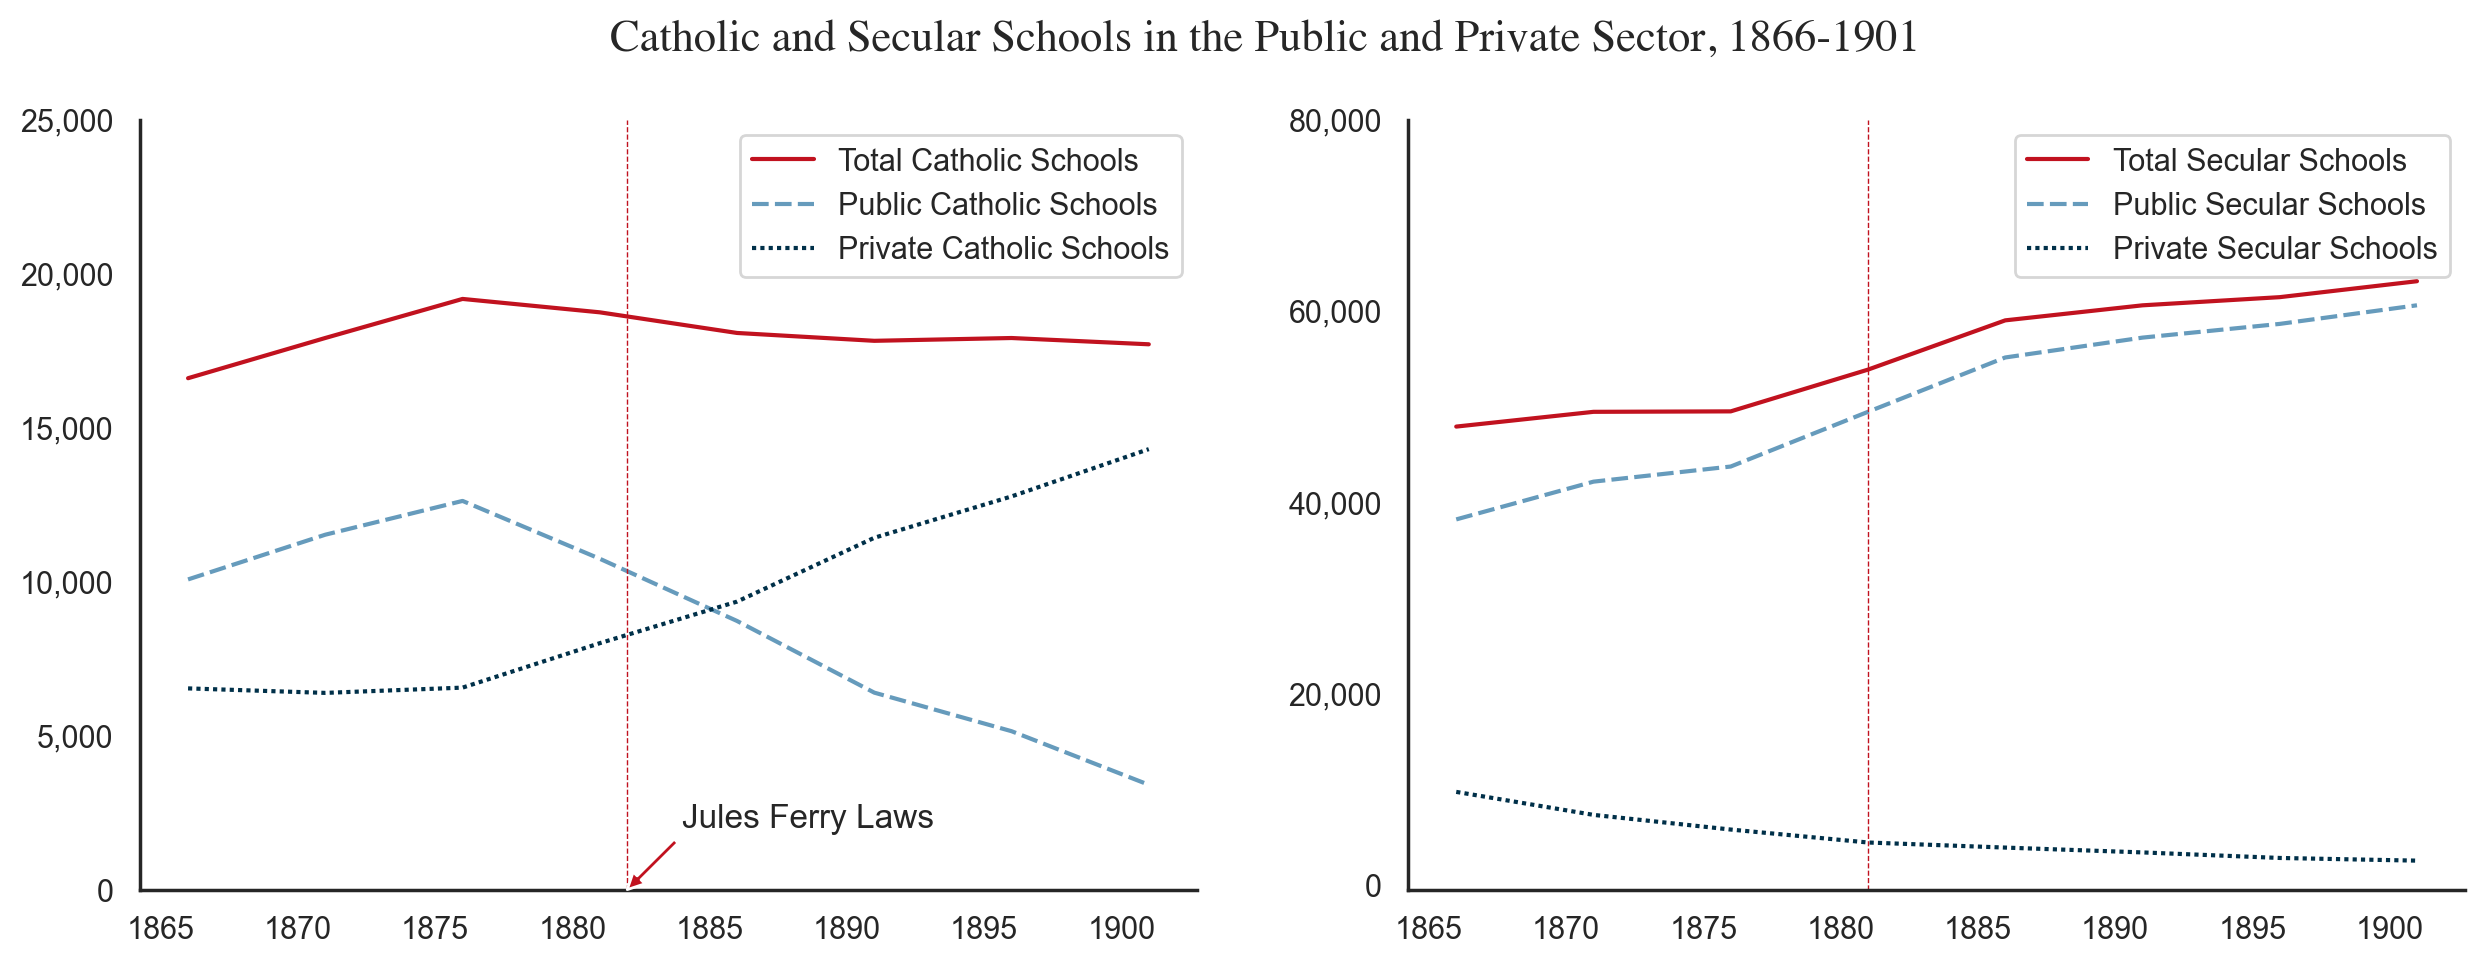

In [13]:

custom_palette = ["#c1121f", "#669bbc", "#003049"]
sns.set_theme(palette=custom_palette, style="white", rc={"axes.spines.top" : False,
                                                              "axes.spines.right" : False,
                                                              "axes.grid" : False,
                                                              "font.family" : "sans-serif", "font.sans-serif" : "Arial",})

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,5), dpi=200)
sns.lineplot(data=schools_long[schools_long["cath"]], x="year", y="Total", hue="School Type", ax=ax1, palette=custom_palette, style="School Type")
sns.lineplot(data=schools_long[~schools_long["cath"]], x="year", y="Total", hue="School Type", ax=ax2, palette=custom_palette, style="School Type")

ax1.set_yticks(np.arange(0,25001, 5000))
ax2.set_yticks(np.arange(0,80001, 20000))
ax1.legend()
ax2.legend()
plt.suptitle("Catholic and Secular Schools in the Public and Private Sector, 1866-1901",
             fontsize=16, fontfamily="Times")
ax1.yaxis.set_major_formatter("{x:,.0f}")
ax2.yaxis.set_major_formatter("{x:,.0f}")
ax1.set(xlabel=None, ylabel=None)
ax2.set(xlabel=None, ylabel=None)
ax2.axvline(1881, lw=0.5, ls="dashed")
ax1.axvline(1882, lw=0.5, ls="dashed")
ax1.annotate(text="Jules Ferry Laws", xy=(1882,0),xytext=(1884, 2000), arrowprops={"headwidth" : 6,
                                                                                   "width" : 2,
                                                                                   "headlength" : 6})
plt.show()


The figure shows a clear divergence between the two school systems. A key event, the Jules Ferry Laws of 1881-1882, represents the key event that explains this pattern. As they made education free and secular, the number of public Catholic schools decreased, while the number of private Catholic schools saw a rise, since private education was not affected by the laws.

This confirms that Catholic education represented an ideological response  against the secularization process.


### Table 12 - Education and employment

It's useful to recap what we have done so far.
1. First, we established that localy religiosity negatively affected the share of industrial workers and the adoption of machines after the Second Industrial Revolution.
2. Second, we demonstrated that most religious areas experienced a higher growth in the number of Catholic schools, suggesting a preference for religious over secular education.
3. Third, we clearly visualized a divergence in the evolution between the two school systems, where the number of private Catholic schools increase just after the French state fostered secular education.

What is missing is the study of the mechanism of transmission: This section analyses how educational choices hindered industrialization by producing workers less equipped for skill-intensive sectors.

To test this, I will use a cohort-level dataset.

In [14]:
cohort_df = pd.read_stata("Data/3b.cohort_dataset.dta")
cohort_labels = var_labels("Data/3b.cohort_dataset.dta")

In [15]:
controls = ["enrol_rate", "lnstud_ps", "lnschools_total"]
order = ["share_cath_schools", "share_cath_stud"]

reg1 = (smf.ols(formula=f"share_cohort_mod_workers ~ share_cath_schools +  + lnpop + C(department_id) + C(year)",
               data=cohort_df)
               .fit(cov_type="cluster",
                    cov_kwds={"groups" : cohort_df["department_id"]}))
               
reg2 = (smf.ols(formula=f"share_cohort_mod_workers ~ share_cath_schools + lnpop + {"+".join(controls)} + C(department_id) + C(year)",
               data=cohort_df)
               .fit(cov_type="cluster",
                    cov_kwds={"groups" : cohort_df["department_id"]}))
               
reg3 = (smf.ols(formula=f"share_cohort_mod_workers ~ share_cath_stud + lnpop +  C(department_id) + C(year)",
               data=cohort_df)
               .fit(cov_type="cluster",
                    cov_kwds={"groups" : cohort_df["department_id"]}))

reg4 = (smf.ols(formula=f"share_cohort_mod_workers ~ share_cath_stud + lnpop + {"+".join(controls)} + C(department_id) + C(year)",
               data=cohort_df)
               .fit(cov_type="cluster",
                    cov_kwds={"groups" : cohort_df["department_id"]}))

In [16]:
info = {"   Schooling controls" : lambda x: "✓" if "lnstud_ps" in x.model.exog_names else "",
        "  Department FE" : lambda x : "✓" if any("C(department_id)" in d for d in x.model.exog_names) else "",
        " Cohort FE" : lambda x  : "✓" if any("C(year)" in y for y in  x.model.exog_names) else "",
        "R2" : lambda x : f"{x.rsquared:.2f}",
        "Obs" : lambda x : f"{x.nobs:.0f}"}

table12 = summary_col([reg1, reg2, reg3, reg4],
            regressor_order=order,
            drop_omitted=True,
            float_format="%.3f",
            stars=True,
            info_dict=info,
            model_names=["(1)", "(2)", "(3)", "(4)"],
            include_r2=False)
table12.add_text("Dependent variable: share of workers in innovative sectors")
table12

,(1),(2),(3),(4)
share_cath_schools,-0.384**,-0.381**,,
,(0.150),(0.154),,
share_cath_stud,,,-0.206*,-0.239**
,,,(0.118),(0.108)
Schooling controls,,✓,,✓
Department FE,✓,✓,✓,✓
Cohort FE,✓,✓,✓,✓
Obs,249,249,249,249
R2,0.97,0.97,0.97,0.97


Table 12 shows a negative association of between the share of catholic schools and catholic students and the share of workers employed in modern sectors. This means cohorts raised in regions with a higher prevalence of Catholic education where significantly less likely to be empoyed in innovative industries.
The coefficients remainst significant and consistent across all specifications.

Department and cohort fixed effects control for the effect of spatial time-invariat characteristics and common macroeconomic shocks to all cohorts. The inclusion of schooling controls (in particular the number of students) demonstrates that the result is not due to a lack of *quantity* of education, but rather to the *content* and *type* of human capital acquired.

Finally, standard errors are clustered at the district level.


### Task 3: Testing alternative mechanism


This final section investigates other mechanism other than education that may have been affected economic development. The purpose is to test whether education remains one of the key driver, or if its impact disappears after we control for other relevant factors. This will determines if the associations shown so far represents spurious correlations or indicates the presence of a real effect of religiosity on economic outcomes.

The key dependent variables are the fertility rate and the vaccination rate, both of which are expected to be correlated with catholic education and economic development. The dataset for this analysis is `dept_data`, already used in the first task.

In [17]:
controls = ["lnpop1871", "mean_lnprec", "mean_lntemp", "wheat_suit", "lnproto_ind", "lndist_Paris", "pays_elections", "enrol_rate1871", "lnsub_dept"]
info = {"  Controls" : lambda x : "✓"	if "lnpop1871" in x.model.exog_names else "",
        " R2" : lambda x : f"{x.rsquared:.2f}",
        "Obs" : lambda x : f"{x.nobs:.0f}"}

mod1 = smf.ols(formula="share_vac_needed ~ share_refractory", data=dept_data).fit(cov_type="HC1")
mod2 = smf.ols(formula=f"share_vac_needed ~ share_refractory + {"+".join(controls)}", data=dept_data).fit(cov_type="HC1")
mod3 = smf.ols(formula="fert_princeton_index ~ share_refractory", data=dept_data).fit(cov_type="HC1")
mod4 = smf.ols(formula=f"fert_princeton_index ~ share_refractory + {"+".join(controls)}", data=dept_data).fit(cov_type="HC1")


In [18]:
table13 = summary_col([mod1, mod2, mod3, mod4],
                      stars = True,
                      include_r2=False,
                      info_dict=info,
                      regressor_order=["share_refractory"],
                      drop_omitted=True,
                      float_format="%.3f",
                      model_names=["(1) Share vaccinations 1871",
                                   "(2) Share vaccinations 1871",
                                   "(3) Fertiliy 1871",
                                   "(4) Fertiliy 1871"])

table13.tables[0].rename(index={"share_refractory" : "Share Refractory"}, inplace=True)
table13

,(1) Share vaccinations 1871,(2) Share vaccinations 1871,(3) Fertiliy 1871,(4) Fertiliy 1871
Share Refractory,-0.248**,-0.260*,0.240***,0.197***
,(0.123),(0.145),(0.060),(0.045)
Controls,,✓,,✓
R2,0.06,0.20,0.20,0.66
Obs,66,62,83,79


The table shows that the degree of religiosity is significantly and negatively associated with health behaviors (share of vaccinations) and fertility rates, both of them are likely to affect economic development. Both variables may have distorted all the previous estimates. To test this, I will include them as control variables in the estimation, replicating Table 9 from the paper.

The dependent variable is the share of industrial employment. The parameter of interest is the sahre of catholic schools. The model includes lagged variables. To create them I will group the data at the department id and order each group by year. Since the dataset provides data each 5 years, I will use `shift` to retrive the variable 2 and 3 rows before for each department. This retrieves its value 10 and 15 years before. 

In [19]:
panel_data = pd.read_stata("Data/3a.panel_dataset.dta")
panel_labels = var_labels("Data/3a.panel_dataset.dta")

panel_data = (panel_data.sort_values(["department_id", "year"])
              .assign(share_cath_schools_l10 = panel_data.groupby("department_id")["share_cath_schools"].shift(2),
                      fertility_l15 = panel_data.groupby("department_id")["fert_princeton_index"].shift(3),
                      vacc_l15 = panel_data.groupby("department_id")["share_vac_needed"].shift(3),
                      phyl_l10 = panel_data.groupby("department_id")["phyl_dummy"].shift(2),
                      lnschools_total_l10 = panel_data.groupby("department_id")["lnschools_total"].shift(2),
                      enrol_rate_l10 = panel_data.groupby("department_id")["enrol_rate"].shift(2),
                      lnstud_ps_l10 = panel_data.groupby("department_id")["lnstud_ps"].shift(2))
              )

panel_data.rename(columns={"yield" : "yield_rnm"},inplace=True) # I renamed yield because it raised an error when I run the model. Probably is a key word in Python.

In [20]:
covariates = ["fertility_l15", "vacc_l15", "phyl_l10", "yield_rnm","lnagr_land", "french_immigrants_p10", "share_urban", "extra_gov_subs_pc", "lnavg_travel_costs"]
schooling_controls = ["enrol_rate_l10", "lnstud_ps_l10", "lnschools_total_l10"] 
fe = ["C(year)", "C(department_id)"]

In [21]:
models = []
for i,cov in enumerate(covariates, start=1):
    model = smf.ols(formula = f"share_ind_act ~ share_cath_schools_l10 + {cov} +  lnpop + {" + ".join(schooling_controls + fe)}", data=panel_data)
    reg = model.fit(cov_type="cluster", cov_kwds={"groups" : panel_data.loc[model.data.row_labels,"department_id"]})
    models.append(reg)


In [22]:
order = ["share_cath_schools_l10"] + covariates
table9 = summary_col(models, regressor_order=order, drop_omitted=True, stars=True,
                     float_format="%.3f")
table9

,share_ind_act I,share_ind_act II,share_ind_act III,share_ind_act IIII,share_ind_act IIIII,share_ind_act IIIIII,share_ind_act IIIIIII,share_ind_act IIIIIIII,share_ind_act IIIIIIIII
share_cath_schools_l10,-0.205***,-0.234**,-0.193***,-0.212***,-0.203**,-0.195***,-0.199***,-0.171**,-0.196***
,(0.071),(0.108),(0.069),(0.078),(0.081),(0.070),(0.068),(0.072),(0.074)
fertility_l15,-0.131,,,,,,,,
,(0.094),,,,,,,,
vacc_l15,,-0.008,,,,,,,
,,(0.010),,,,,,,
phyl_l10,,,0.000,,,,,,
,,,(0.005),,,,,,
yield_rnm,,,,0.000,,,,,
,,,,(0.002),,,,,


As it is evident, the coefficient of the share of catholic schools remain significant across all specifications. This ultimately prove that education was the key driver.